In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
customers = pd.read_csv("../data/cleaned/customers_cleaned.csv")
products = pd.read_csv("../data/cleaned/products_cleaned.csv")
orders = pd.read_csv("../data/cleaned/orders_cleaned.csv")
marketing = pd.read_csv("../data/cleaned/marketing_campaigns_cleaned.csv")
interactions = pd.read_csv("../data/cleaned/customer_interactions_cleaned.csv")
expenses = pd.read_csv("../data/cleaned/expenses_cleaned.csv")
returns = pd.read_csv("../data/cleaned/returns_cleaned.csv")

print("All cleaned datasets loaded successfully!")

All cleaned datasets loaded successfully!


In [4]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
expenses["expense_date"] = pd.to_datetime(expenses["expense_date"])
marketing["campaign_date"] = pd.to_datetime(marketing["campaign_date"])
returns["return_date"] = pd.to_datetime(returns["return_date"])

print("Date columns converted successfully!")

Date columns converted successfully!


In [5]:
# Gross Revenue
orders["gross_revenue"] = (
    orders["quantity"] * orders["unit_price"]
)

# Discount Amount
orders["discount_amount"] = (
    orders["gross_revenue"] * orders["discount_percent"] / 100
)

# Net Revenue
orders["net_revenue"] = (
    orders["gross_revenue"] - orders["discount_amount"]
)

print("Revenue metrics created successfully!")

orders.head()

Revenue metrics created successfully!


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_percent,payment_method,order_status,gross_revenue,discount_amount,net_revenue
0,O100000,C101341,P1280,2025-06-28,2,6428.58,10,UPI,Delivered,12857.16,1285.716,11571.444
1,O100001,C100981,P1252,2025-07-30,4,1455.88,0,UPI,Delivered,5823.52,0.000,5823.520
2,O100002,C109509,P1371,2025-06-29,4,3225.49,10,Credit Card,Delivered,12901.96,1290.196,11611.764
3,O100003,C101497,P1421,2025-03-30,2,3737.93,10,UPI,Delivered,7475.86,747.586,6728.274
4,O100004,C101120,P1302,2025-09-13,4,3921.72,20,Debit Card,Delivered,15686.88,3137.376,12549.504


In [6]:
# Business KPIs

total_orders = len(orders)

total_customers = orders["customer_id"].nunique()

total_gross_revenue = orders["gross_revenue"].sum()

total_discount = orders["discount_amount"].sum()

total_net_revenue = orders["net_revenue"].sum()

average_order_value = orders["net_revenue"].mean()

delivered_orders = (orders["order_status"] == "Delivered").sum()

cancelled_orders = (orders["order_status"] == "Cancelled").sum()


print("STARTUP BUSINESS KPIs")
print("=" * 40)

print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Gross Revenue: ₹{total_gross_revenue:,.2f}")
print(f"Total Discount: ₹{total_discount:,.2f}")
print(f"Net Revenue: ₹{total_net_revenue:,.2f}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Delivered Orders: {delivered_orders:,}")
print(f"Cancelled Orders: {cancelled_orders:,}")

STARTUP BUSINESS KPIs
Total Orders: 60,000
Total Customers: 9,976
Gross Revenue: ₹535,650,755.01
Total Discount: ₹32,005,681.96
Net Revenue: ₹503,645,073.05
Average Order Value: ₹8,394.08
Delivered Orders: 56,443
Cancelled Orders: 3,557


In [7]:
# Create month column

orders["month"] = orders["order_date"].dt.to_period("M")

# Calculate monthly net revenue

monthly_revenue = (
    orders
    .groupby("month")["net_revenue"]
    .sum()
    .reset_index()
)

# Convert month to string for visualization

monthly_revenue["month"] = monthly_revenue["month"].astype(str)

# Display monthly revenue

monthly_revenue

,month,net_revenue
0,2025-01,2.650921e+07
1,2025-02,2.404099e+07
2,2025-03,2.604751e+07
3,2025-04,2.632767e+07
4,2025-05,2.717935e+07
5,2025-06,2.619861e+07
6,2025-07,2.667107e+07
7,2025-08,2.600792e+07
8,2025-09,2.593578e+07
9,2025-10,2.619482e+07


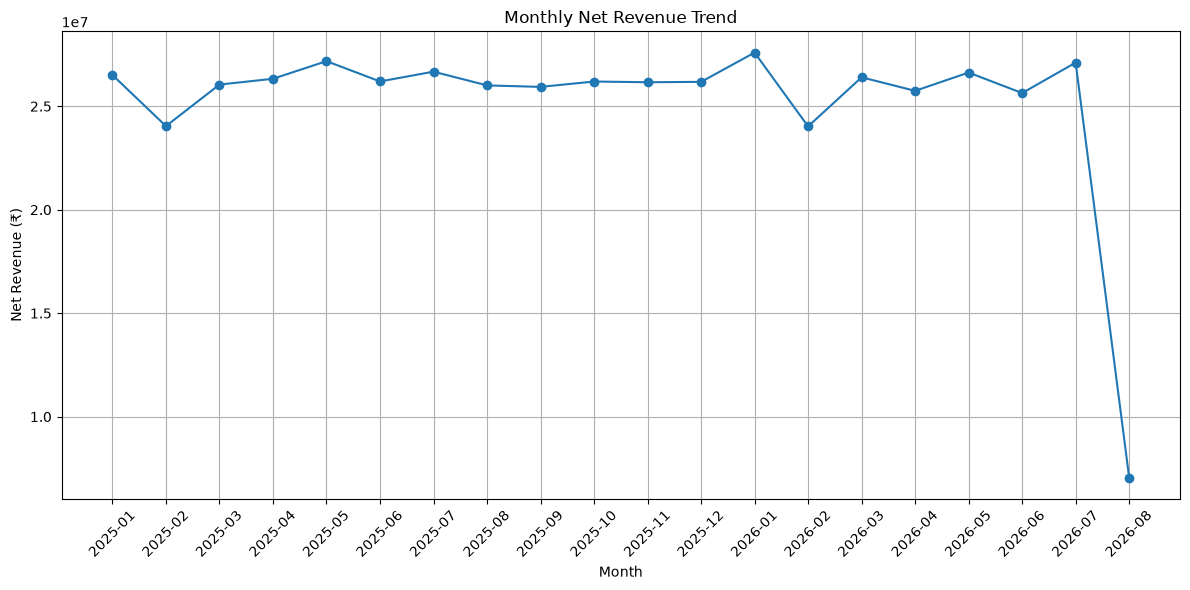

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["net_revenue"],
    marker="o"
)

plt.title("Monthly Net Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue (₹)")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [9]:
# Merge orders with products

product_sales = orders.merge(
    products,
    on="product_id",
    how="left"
)

# Calculate revenue by product

top_products = (
    product_sales
    .groupby("product_name")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("TOP 10 PRODUCTS BY NET REVENUE")
print(top_products)

TOP 10 PRODUCTS BY NET REVENUE
product_name
Sneakers 316            2.671823e+06
Sunscreen 357           2.456967e+06
Sneakers 492            2.444263e+06
Bluetooth Speaker 93    2.439348e+06
Storage Box 425         2.350453e+06
Table Lamp 215          2.299453e+06
Perfume 456             2.248468e+06
Face Wash 269           2.243503e+06
Sneakers 3              2.227348e+06
Yoga Mat 168            2.219606e+06
Name: net_revenue, dtype: float64


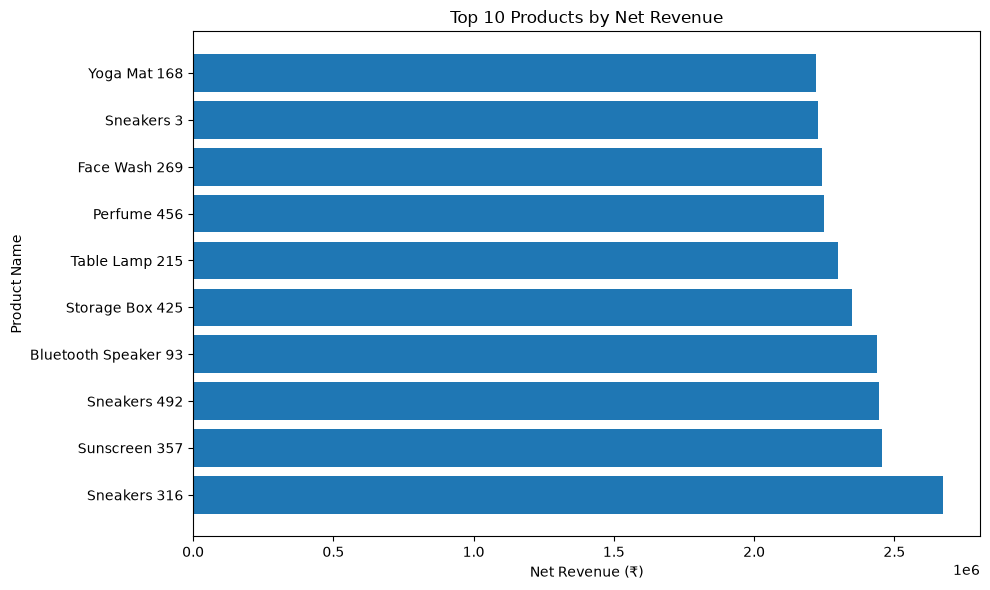

In [10]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Products by Net Revenue")
plt.xlabel("Net Revenue (₹)")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

In [11]:
# Calculate revenue by category

category_sales = (
    product_sales
    .groupby("category")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("SALES BY CATEGORY")
print(category_sales)

SALES BY CATEGORY
category
Home & Kitchen    1.084746e+08
Beauty            1.053574e+08
Fashion           1.048022e+08
Electronics       9.371496e+07
Fitness           9.129597e+07
Name: net_revenue, dtype: float64


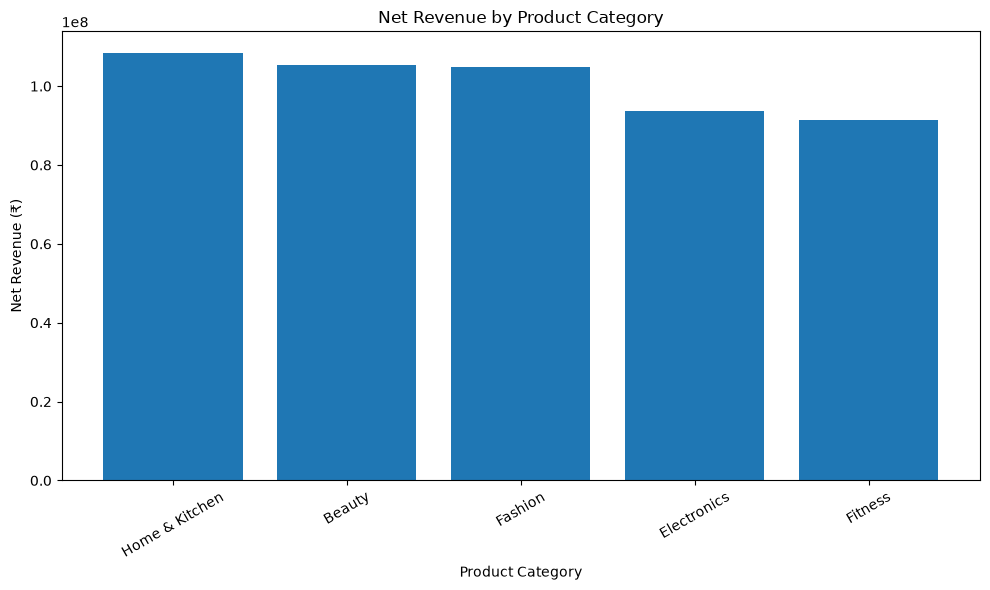

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Net Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Net Revenue (₹)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [13]:
# Merge orders with customer information

city_sales = orders.merge(
    customers[["customer_id", "city"]],
    on="customer_id",
    how="left"
)

# Calculate revenue by city

city_revenue = (
    city_sales
    .groupby("city")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("TOP PERFORMING CITIES BY NET REVENUE")
print(city_revenue)

TOP PERFORMING CITIES BY NET REVENUE
city
Delhi            5.288811e+07
Hyderabad        5.233858e+07
Pune             5.133259e+07
Ahmedabad        5.121275e+07
Kolkata          5.097395e+07
Mumbai           5.092621e+07
Kakinada         4.996796e+07
Bengaluru        4.902477e+07
Chennai          4.791180e+07
Visakhapatnam    4.706836e+07
Name: net_revenue, dtype: float64


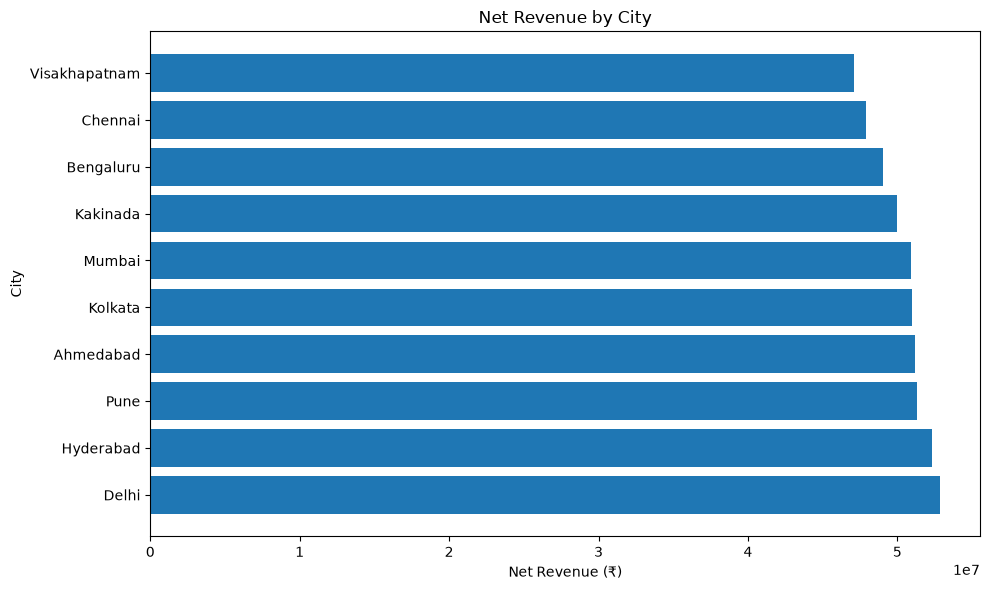

In [14]:
plt.figure(figsize=(10, 6))

plt.barh(
    city_revenue.index,
    city_revenue.values
)

plt.title("Net Revenue by City")
plt.xlabel("Net Revenue (₹)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [15]:
# Merge orders with customer acquisition information

channel_analysis = orders.merge(
    customers[["customer_id", "acquisition_channel"]],
    on="customer_id",
    how="left"
)

# Calculate performance by acquisition channel

acquisition_performance = (
    channel_analysis
    .groupby("acquisition_channel")
    .agg(
        total_customers=("customer_id", "nunique"),
        total_orders=("order_id", "count"),
        net_revenue=("net_revenue", "sum")
    )
    .sort_values("net_revenue", ascending=False)
)

print("CUSTOMER ACQUISITION CHANNEL PERFORMANCE")
acquisition_performance

CUSTOMER ACQUISITION CHANNEL PERFORMANCE


,total_customers,total_orders,net_revenue
acquisition_channel,,,
Google Ads,2364,14107,1.182485e+08
Instagram,2184,13247,1.122703e+08
Organic Search,1819,10898,9.205312e+07
Referral,1414,8625,7.087488e+07
Email,1222,7312,6.137465e+07
YouTube,973,5811,4.882365e+07


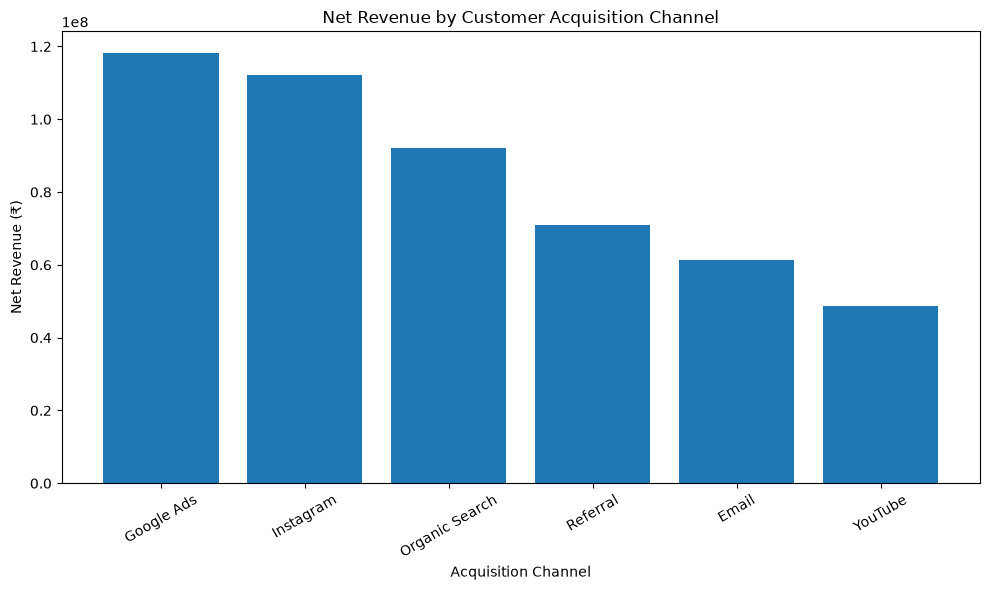

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    acquisition_performance.index,
    acquisition_performance["net_revenue"]
)

plt.title("Net Revenue by Customer Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Net Revenue (₹)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [17]:
# View marketing dataset structure

print(marketing.columns.tolist())

marketing.head()

['campaign_id', 'campaign_name', 'channel', 'campaign_date', 'spend', 'impressions', 'clicks', 'leads', 'conversions']


,campaign_id,campaign_name,channel,campaign_date,spend,impressions,clicks,leads,conversions
0,M1000,Referral Campaign 1,Referral,2026-01-20,177948.19,456395,16665,5034,977
1,M1001,Email Campaign 2,Email,2026-05-27,48246.98,568772,19725,2095,278
2,M1002,YouTube Campaign 3,YouTube,2025-06-02,61800.92,570784,7931,1329,370
3,M1003,Referral Campaign 4,Referral,2025-03-15,175759.61,71119,1316,413,60
4,M1004,Email Campaign 5,Email,2025-04-14,187673.54,584163,16594,3743,269


In [18]:
# Create marketing performance metrics

marketing["CTR (%)"] = (
    marketing["clicks"] / marketing["impressions"] * 100
)

marketing["Conversion Rate (%)"] = (
    marketing["conversions"] / marketing["clicks"] * 100
)

marketing["Cost Per Click"] = (
    marketing["spend"] / marketing["clicks"]
)

marketing["Cost Per Lead"] = (
    marketing["spend"] / marketing["leads"]
)

marketing["Cost Per Conversion"] = (
    marketing["spend"] / marketing["conversions"]
)

print("Marketing metrics created successfully!")

marketing.head()

Marketing metrics created successfully!


,campaign_id,campaign_name,channel,campaign_date,spend,impressions,clicks,leads,conversions,CTR (%),Conversion Rate (%),Cost Per Click,Cost Per Lead,Cost Per Conversion
0,M1000,Referral Campaign 1,Referral,2026-01-20,177948.19,456395,16665,5034,977,3.651442,5.862586,10.677959,35.349263,182.137349
1,M1001,Email Campaign 2,Email,2026-05-27,48246.98,568772,19725,2095,278,3.467998,1.409379,2.445981,23.029585,173.550288
2,M1002,YouTube Campaign 3,YouTube,2025-06-02,61800.92,570784,7931,1329,370,1.389492,4.665238,7.792324,46.501821,167.029514
3,M1003,Referral Campaign 4,Referral,2025-03-15,175759.61,71119,1316,413,60,1.850420,4.559271,133.555935,425.568063,2929.326833
4,M1004,Email Campaign 5,Email,2025-04-14,187673.54,584163,16594,3743,269,2.840646,1.621068,11.309723,50.139872,697.671152


In [19]:
channel_marketing = (
    marketing
    .groupby("channel")
    .agg(
        total_spend=("spend", "sum"),
        total_impressions=("impressions", "sum"),
        total_clicks=("clicks", "sum"),
        total_leads=("leads", "sum"),
        total_conversions=("conversions", "sum")
    )
)

# Calculate channel-level metrics

channel_marketing["CTR (%)"] = (
    channel_marketing["total_clicks"]
    / channel_marketing["total_impressions"]
    * 100
)

channel_marketing["Conversion Rate (%)"] = (
    channel_marketing["total_conversions"]
    / channel_marketing["total_clicks"]
    * 100
)

channel_marketing["Cost Per Conversion"] = (
    channel_marketing["total_spend"]
    / channel_marketing["total_conversions"]
)

# Sort by conversions

channel_marketing = channel_marketing.sort_values(
    "total_conversions",
    ascending=False
)

print("MARKETING CHANNEL PERFORMANCE")

channel_marketing.round(2)

MARKETING CHANNEL PERFORMANCE


,total_spend,total_impressions,total_clicks,total_leads,total_conversions,CTR (%),Conversion Rate (%),Cost Per Conversion
channel,,,,,,,,
Google Ads,5078358.47,22017163,1154298,235061,37564,5.24,3.25,135.19
Instagram,5016067.96,23529002,1131070,185143,35514,4.81,3.14,141.24
Email,4766099.17,22287223,988892,192671,31267,4.44,3.16,152.43
YouTube,3850029.10,17572005,728251,143089,26120,4.14,3.59,147.40
Referral,3102154.63,14128919,669056,135214,24285,4.74,3.63,127.74


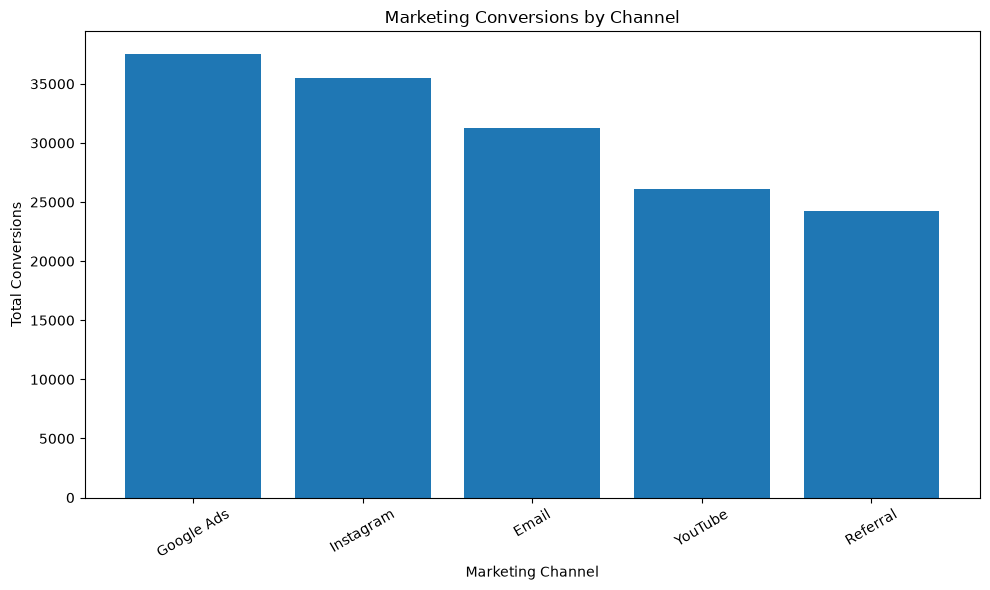

In [20]:
plt.figure(figsize=(10, 6))

plt.bar(
    channel_marketing.index,
    channel_marketing["total_conversions"]
)

plt.title("Marketing Conversions by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Conversions")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [21]:
# Merge orders with product cost information

profit_analysis = orders.merge(
    products[["product_id", "cost_price"]],
    on="product_id",
    how="left"
)

# Calculate product cost

profit_analysis["total_cost"] = (
    profit_analysis["quantity"] * profit_analysis["cost_price"]
)

# Calculate gross profit

profit_analysis["gross_profit"] = (
    profit_analysis["net_revenue"]
    - profit_analysis["total_cost"]
)

print("Profit analysis dataset created successfully!")

profit_analysis.head()

Profit analysis dataset created successfully!


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_percent,payment_method,order_status,gross_revenue,discount_amount,net_revenue,month,cost_price,total_cost,gross_profit
0,O100000,C101341,P1280,2025-06-28,2,6428.58,10,UPI,Delivered,12857.16,1285.716,11571.444,2025-06,3458.70,6917.40,4654.044
1,O100001,C100981,P1252,2025-07-30,4,1455.88,0,UPI,Delivered,5823.52,0.000,5823.520,2025-07,814.29,3257.16,2566.360
2,O100002,C109509,P1371,2025-06-29,4,3225.49,10,Credit Card,Delivered,12901.96,1290.196,11611.764,2025-06,2147.13,8588.52,3023.244
3,O100003,C101497,P1421,2025-03-30,2,3737.93,10,UPI,Delivered,7475.86,747.586,6728.274,2025-03,1861.18,3722.36,3005.914
4,O100004,C101120,P1302,2025-09-13,4,3921.72,20,Debit Card,Delivered,15686.88,3137.376,12549.504,2025-09,2460.58,9842.32,2707.184


In [22]:
# Calculate overall business profitability

total_net_revenue = profit_analysis["net_revenue"].sum()

total_product_cost = profit_analysis["total_cost"].sum()

total_gross_profit = profit_analysis["gross_profit"].sum()

total_expenses = expenses["amount"].sum()

total_refund_amount = returns["refund_amount"].sum()

estimated_business_profit = (
    total_gross_profit
    - total_expenses
    - total_refund_amount
)

profit_margin = (
    estimated_business_profit / total_net_revenue
) * 100


print("STARTUP PROFITABILITY ANALYSIS")
print("=" * 45)

print(f"Total Net Revenue: ₹{total_net_revenue:,.2f}")
print(f"Total Product Cost: ₹{total_product_cost:,.2f}")
print(f"Gross Profit: ₹{total_gross_profit:,.2f}")
print(f"Operating Expenses: ₹{total_expenses:,.2f}")
print(f"Refund Amount: ₹{total_refund_amount:,.2f}")

print("-" * 45)

print(f"Estimated Business Profit: ₹{estimated_business_profit:,.2f}")
print(f"Estimated Profit Margin: {profit_margin:.2f}%")

STARTUP PROFITABILITY ANALYSIS
Total Net Revenue: ₹503,645,073.05
Total Product Cost: ₹315,811,769.07
Gross Profit: ₹187,833,303.98
Operating Expenses: ₹380,126,798.24
Refund Amount: ₹49,110,482.58
---------------------------------------------
Estimated Business Profit: ₹-241,403,976.84
Estimated Profit Margin: -47.93%


In [23]:
# Create month column from order date

profit_analysis["month"] = (
    pd.to_datetime(profit_analysis["order_date"])
    .dt.to_period("M")
)

# Monthly revenue, cost and gross profit

monthly_profit = (
    profit_analysis
    .groupby("month")
    .agg(
        net_revenue=("net_revenue", "sum"),
        total_cost=("total_cost", "sum"),
        gross_profit=("gross_profit", "sum")
    )
    .reset_index()
)

monthly_profit["month"] = monthly_profit["month"].astype(str)

monthly_profit

,month,net_revenue,total_cost,gross_profit
0,2025-01,2.650921e+07,16591955.55,9.917254e+06
1,2025-02,2.404099e+07,15003653.19,9.037334e+06
2,2025-03,2.604751e+07,16411940.37,9.635574e+06
3,2025-04,2.632767e+07,16520140.96,9.807532e+06
4,2025-05,2.717935e+07,17041189.89,1.013816e+07
5,2025-06,2.619861e+07,16508488.69,9.690119e+06
6,2025-07,2.667107e+07,16690778.03,9.980290e+06
7,2025-08,2.600792e+07,16294101.79,9.713820e+06
8,2025-09,2.593578e+07,16335994.95,9.599780e+06
9,2025-10,2.619482e+07,16417981.99,9.776833e+06


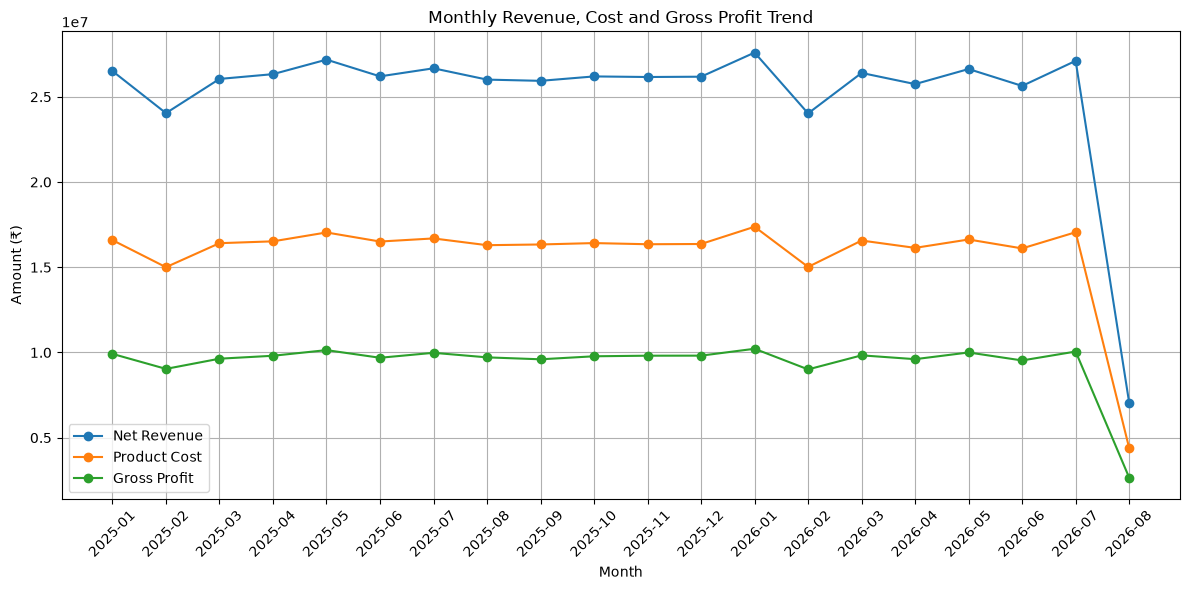

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_profit["month"],
    monthly_profit["net_revenue"],
    marker="o",
    label="Net Revenue"
)

plt.plot(
    monthly_profit["month"],
    monthly_profit["total_cost"],
    marker="o",
    label="Product Cost"
)

plt.plot(
    monthly_profit["month"],
    monthly_profit["gross_profit"],
    marker="o",
    label="Gross Profit"
)

plt.title("Monthly Revenue, Cost and Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [25]:
print("EXPENSES COLUMNS:")
print(expenses.columns.tolist())

print("\nRETURNS COLUMNS:")
print(returns.columns.tolist())

EXPENSES COLUMNS:
['expense_id', 'expense_date', 'expense_category', 'department', 'amount']

RETURNS COLUMNS:
['return_id', 'order_id', 'customer_id', 'product_id', 'return_date', 'return_reason', 'refund_amount']


In [26]:
print("\nEXPENSES:")
display(expenses.head())

print("\nRETURNS:")
display(returns.head())


EXPENSES:


,expense_id,expense_date,expense_category,department,amount
0,E10000,2025-12-08,Infrastructure,Technology,78402.16
1,E10001,2026-02-15,Salaries,HR,122401.25
2,E10002,2025-03-01,Operations,Operations,141663.33
3,E10003,2025-08-20,Operations,Operations,37764.66
4,E10004,2026-08-02,Operations,Operations,118295.27



RETURNS:


,return_id,order_id,customer_id,product_id,return_date,return_reason,refund_amount
0,R10000,O119505,C107113,P1260,2025-01-27,Late Delivery,647.41
1,R10001,O125902,C100550,P1022,2026-08-25,Late Delivery,6263.34
2,R10002,O123006,C109269,P1177,2026-06-04,Wrong Product,7308.43
3,R10003,O145900,C107267,P1261,2026-03-31,Damaged Product,3600.99
4,R10004,O105277,C106890,P1287,2026-05-30,Late Delivery,7134.84


In [27]:
# Convert date columns to datetime

expenses["expense_date"] = pd.to_datetime(expenses["expense_date"])
returns["return_date"] = pd.to_datetime(returns["return_date"])

# Create month columns

expenses["month"] = expenses["expense_date"].dt.to_period("M").astype(str)

returns["month"] = returns["return_date"].dt.to_period("M").astype(str)

print("Expense and return dates processed successfully!")

Expense and return dates processed successfully!


In [28]:
# Monthly operating expenses

monthly_expenses = (
    expenses
    .groupby("month")["amount"]
    .sum()
    .reset_index()
)

monthly_expenses.columns = ["month", "operating_expenses"]


# Monthly refund amounts

monthly_refunds = (
    returns
    .groupby("month")["refund_amount"]
    .sum()
    .reset_index()
)

monthly_refunds.columns = ["month", "refund_amount"]


print("Monthly expenses and refunds calculated successfully!")

display(monthly_expenses.head())

display(monthly_refunds.head())

Monthly expenses and refunds calculated successfully!


,month,operating_expenses
0,2025-01,19570203.84
1,2025-02,19657887.34
2,2025-03,19724660.11
3,2025-04,18864300.41
4,2025-05,21548269.15


,month,refund_amount
0,2025-01,1303574.15
1,2025-02,2360064.17
2,2025-03,2324623.26
3,2025-04,2720130.47
4,2025-05,2687086.21


In [29]:
# Merge revenue, cost, expenses and refunds

monthly_business_profit = monthly_profit.merge(
    monthly_expenses,
    on="month",
    how="left"
)

monthly_business_profit = monthly_business_profit.merge(
    monthly_refunds,
    on="month",
    how="left"
)

# Replace missing values with 0

monthly_business_profit["operating_expenses"] = (
    monthly_business_profit["operating_expenses"].fillna(0)
)

monthly_business_profit["refund_amount"] = (
    monthly_business_profit["refund_amount"].fillna(0)
)

# Calculate estimated business profit

monthly_business_profit["estimated_profit"] = (
    monthly_business_profit["gross_profit"]
    - monthly_business_profit["operating_expenses"]
    - monthly_business_profit["refund_amount"]
)

# Calculate profit margin

monthly_business_profit["profit_margin"] = (
    monthly_business_profit["estimated_profit"]
    / monthly_business_profit["net_revenue"]
) * 100


print("MONTHLY BUSINESS PROFITABILITY ANALYSIS")
print("=" * 50)

display(monthly_business_profit)

MONTHLY BUSINESS PROFITABILITY ANALYSIS


,month,net_revenue,total_cost,gross_profit,operating_expenses,refund_amount,estimated_profit,profit_margin
0,2025-01,2.650921e+07,16591955.55,9.917254e+06,19570203.84,1303574.15,-1.095652e+07,-41.331007
1,2025-02,2.404099e+07,15003653.19,9.037334e+06,19657887.34,2360064.17,-1.298062e+07,-53.993694
2,2025-03,2.604751e+07,16411940.37,9.635574e+06,19724660.11,2324623.26,-1.241371e+07,-47.657942
3,2025-04,2.632767e+07,16520140.96,9.807532e+06,18864300.41,2720130.47,-1.177690e+07,-44.732016
4,2025-05,2.717935e+07,17041189.89,1.013816e+07,21548269.15,2687086.21,-1.409720e+07,-51.867315
5,2025-06,2.619861e+07,16508488.69,9.690119e+06,17336880.33,2774712.44,-1.042147e+07,-39.778730
6,2025-07,2.667107e+07,16690778.03,9.980290e+06,21055468.34,2503268.26,-1.357845e+07,-50.910772
7,2025-08,2.600792e+07,16294101.79,9.713820e+06,21960864.51,2589864.16,-1.483691e+07,-57.047649
8,2025-09,2.593578e+07,16335994.95,9.599780e+06,19415850.15,2688442.56,-1.250451e+07,-48.213375
9,2025-10,2.619482e+07,16417981.99,9.776833e+06,20097243.84,2333056.76,-1.265347e+07,-48.305235


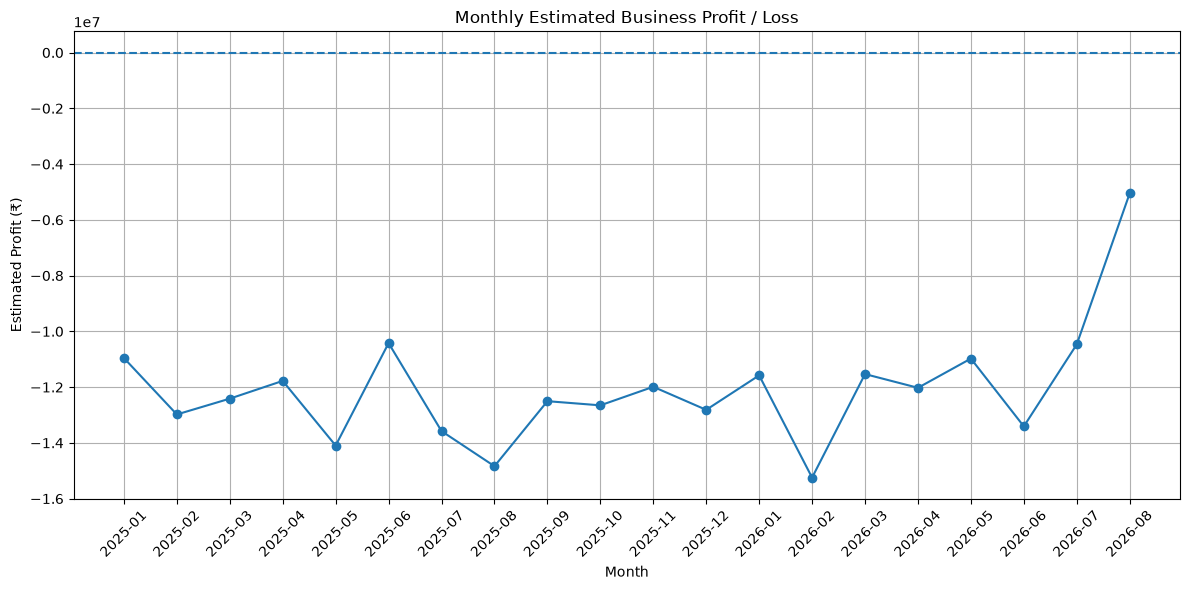

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_business_profit["month"],
    monthly_business_profit["estimated_profit"],
    marker="o"
)

plt.axhline(y=0, linestyle="--")

plt.title("Monthly Estimated Business Profit / Loss")
plt.xlabel("Month")
plt.ylabel("Estimated Profit (₹)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
# EXPENSE ANALYSIS

# Total expenses by category

expense_by_category = (
    expenses
    .groupby("expense_category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

print("EXPENSES BY CATEGORY")
print("=" * 40)

display(expense_by_category)

EXPENSES BY CATEGORY


expense_category
Infrastructure      55705371.98
Marketing           55089694.54
Logistics           54918179.55
Customer Support    54082335.42
Technology          53607054.90
Operations          53423167.00
Salaries            53300994.85
Name: amount, dtype: float64

In [32]:
# Total expenses by department

expense_by_department = (
    expenses
    .groupby("department")["amount"]
    .sum()
    .sort_values(ascending=False)
)

print("EXPENSES BY DEPARTMENT")
print("=" * 40)

display(expense_by_department)

EXPENSES BY DEPARTMENT


department
Technology    1.093124e+08
Operations    1.083413e+08
Marketing     5.508969e+07
Support       5.408234e+07
HR            5.330099e+07
Name: amount, dtype: float64

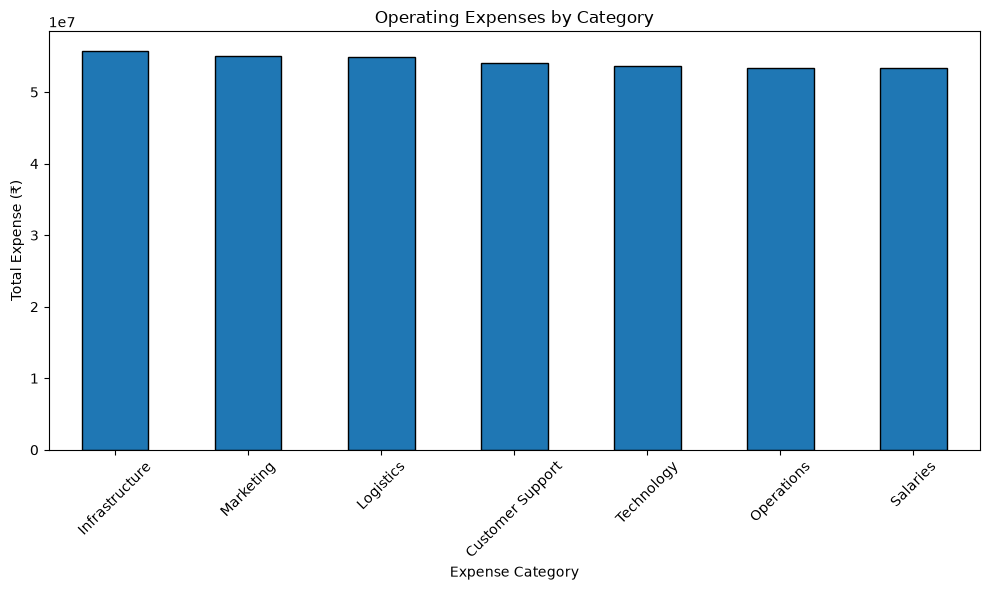

In [33]:
# Expense by category chart

plt.figure(figsize=(10, 6))

expense_by_category.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Operating Expenses by Category")
plt.xlabel("Expense Category")
plt.ylabel("Total Expense (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

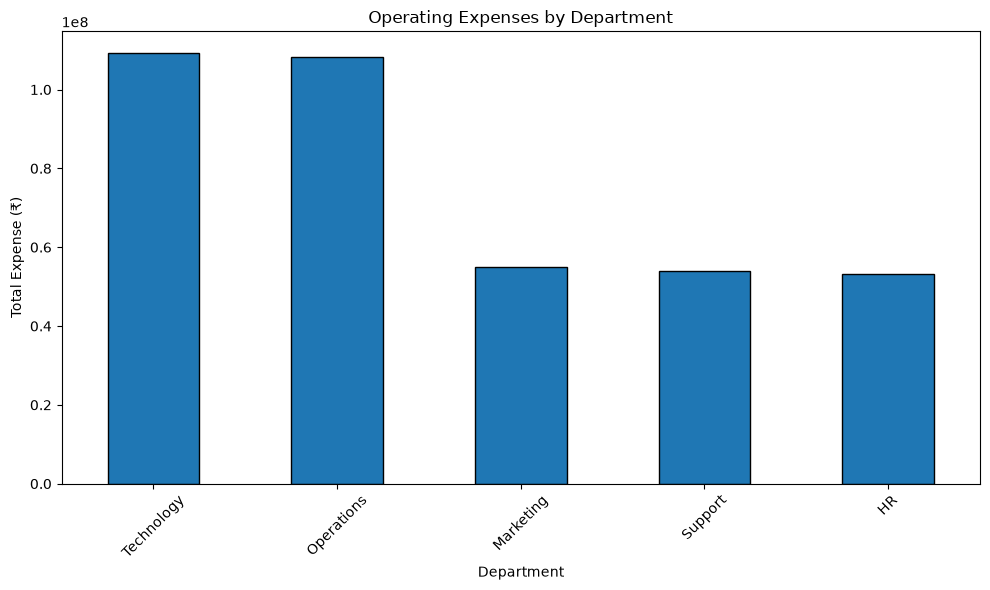

In [34]:
# Expense by department chart

plt.figure(figsize=(10, 6))

expense_by_department.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Operating Expenses by Department")
plt.xlabel("Department")
plt.ylabel("Total Expense (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [35]:
# RETURN & REFUND ANALYSIS

return_reason_analysis = (
    returns
    .groupby("return_reason")
    .agg(
        total_returns=("return_id", "count"),
        total_refund=("refund_amount", "sum")
    )
    .sort_values("total_refund", ascending=False)
)

print("RETURN & REFUND ANALYSIS")
print("=" * 45)

display(return_reason_analysis)

RETURN & REFUND ANALYSIS


,total_returns,total_refund
return_reason,,
Late Delivery,1227,10169478.68
Changed Mind,1212,10041950.60
Damaged Product,1222,9808109.26
Quality Issue,1155,9807150.58
Wrong Product,1184,9283793.46


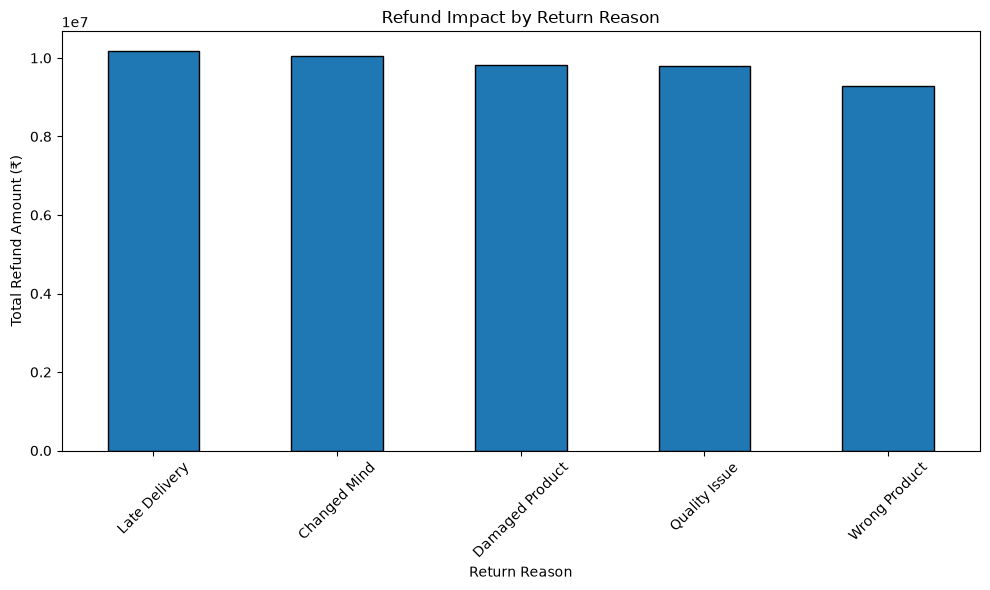

In [36]:
plt.figure(figsize=(10, 6))

return_reason_analysis["total_refund"].plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Refund Impact by Return Reason")
plt.xlabel("Return Reason")
plt.ylabel("Total Refund Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()